In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import tarfile

os.makedirs("/root/.keras/datasets/", exist_ok=True)

# Copiar desde la carpeta correcta
!cp "/content/drive/MyDrive/Evaluacion 1 Deep Learning/simpsons_train.tar.gz" "/root/.keras/datasets/simpsons_train.tar.gz"
!cp "/content/drive/MyDrive/Evaluacion 1 Deep Learning/simpsons_test.tar.gz" "/root/.keras/datasets/simpsons_test.tar.gz"

# Descomprimir
!tar -xzf "/root/.keras/datasets/simpsons_train.tar.gz" -C "/root/.keras/datasets/"
!tar -xzf "/root/.keras/datasets/simpsons_test.tar.gz" -C "/root/.keras/datasets/"

print("LISTO")

Mounted at /content/drive
LISTO


In [2]:
# Verificar carpetas
!ls /root/.keras/datasets/simpsons/ | head -10
!ls /root/.keras/datasets/simpsons_testset/ | head -10

abraham_grampa_simpson
agnes_skinner
apu_nahasapeemapetilon
barney_gumble
bart_simpson
bumblebee_man
carl_carlson
charles_montgomery_burns
chief_wiggum
cletus_spuckler
abraham_grampa_simpson_0.jpg
abraham_grampa_simpson_10.jpg
abraham_grampa_simpson_11.jpg
abraham_grampa_simpson_12.jpg
abraham_grampa_simpson_13.jpg
abraham_grampa_simpson_14.jpg
abraham_grampa_simpson_15.jpg
abraham_grampa_simpson_16.jpg
abraham_grampa_simpson_17.jpg
abraham_grampa_simpson_18.jpg


In [3]:
from google.colab.patches import cv2_imshow
import cv2
import os
import numpy as np
import keras
import glob
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Model
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten, BatchNormalization
from keras.optimizers import Adam, SGD
from sklearn.metrics import confusion_matrix, classification_report
import itertools

# Mapeo de personajes
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

IMG_SIZE = 64

def load_train_set(dirname, map_characters, verbose=True):
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
            print("Leyendo {} imágenes de {}".format(len(images), character))
        for image_name in images:
            image = cv2.imread(os.path.join(dirname, character, image_name))
            X_train.append(cv2.resize(image, (IMG_SIZE, IMG_SIZE)))
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

def load_test_set(dirname, map_characters, verbose=True):
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)

# Cargar datos
DATASET_TRAIN_PATH = "/root/.keras/datasets/simpsons"
DATASET_TEST_PATH = "/root/.keras/datasets/simpsons_testset"

X, y = load_train_set(DATASET_TRAIN_PATH, MAP_CHARACTERS)
X_t, y_t = load_test_set(DATASET_TEST_PATH, MAP_CHARACTERS)

# Barajar
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

# Normalizar
X = X / 255.0
X_t = X_t / 255.0

print("✅ Datos listos")

Leyendo 913 imágenes de abraham_grampa_simpson
Leyendo 623 imágenes de apu_nahasapeemapetilon
Leyendo 1342 imágenes de bart_simpson
Leyendo 1193 imágenes de charles_montgomery_burns
Leyendo 986 imágenes de chief_wiggum
Leyendo 469 imágenes de comic_book_guy
Leyendo 457 imágenes de edna_krabappel
Leyendo 2246 imágenes de homer_simpson
Leyendo 498 imágenes de kent_brockman
Leyendo 1206 imágenes de krusty_the_clown
Leyendo 1354 imágenes de lisa_simpson
Leyendo 1291 imágenes de marge_simpson
Leyendo 1079 imágenes de milhouse_van_houten
Leyendo 1452 imágenes de moe_szyslak
Leyendo 1454 imágenes de ned_flanders
Leyendo 358 imágenes de nelson_muntz
Leyendo 1194 imágenes de principal_skinner
Leyendo 877 imágenes de sideshow_bob
Leídas 890 imágenes de test
✅ Datos listos


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Validación: {X_val.shape}")
print(f"Prueba: {X_t.shape}")

Entrenamiento: (15193, 64, 64, 3)
Validación: (3799, 64, 64, 3)
Prueba: (890, 64, 64, 3)


In [5]:
# ============================================
# 3. DIVIDIR TRAIN/VALIDATION
# ============================================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Validación: {X_val.shape}")
print(f"Prueba: {X_t.shape}")

Entrenamiento: (15193, 64, 64, 3)
Validación: (3799, 64, 64, 3)
Prueba: (890, 64, 64, 3)


In [6]:
# Semillas para reproducibilidad
np.random.seed(30)
tf.random.set_seed(30)

# Parámetros
IMG_SIZE = 64
N = IMG_SIZE * IMG_SIZE * 3  # 12288 neuronas de entrada
C = len(MAP_CHARACTERS)      # 18 neuronas de salida

# Capas ocultas
h1 = 512
h2 = 256
h3 = 128
h4 = 64

# Crear red
red = keras.Sequential()
red.add(keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)))
red.add(keras.layers.Dense(h1, activation='relu'))
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.Dense(h3, activation='relu'))
red.add(keras.layers.Dense(h4, activation='relu'))
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()

red.compile(
    loss='sparse_categorical_crossentropy',  # porque tus labels son números 0-17
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,465,618 (24.66 MB)

 Trainable params: 6,465,618 (24.66 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = red.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1759 - loss: 2.6551 - val_accuracy: 0.2258 - val_loss: 2.4577
Epoch 2/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2746 - loss: 2.3593 - val_accuracy: 0.3053 - val_loss: 2.2483
Epoch 3/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3436 - loss: 2.1624 - val_accuracy: 0.3525 - val_loss: 2.1252
Epoch 4/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3847 - loss: 2.0371 - val_accuracy: 0.3698 - val_loss: 2.0737
Epoch 5/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4158 - loss: 1.9416 - val_accuracy: 0.3883 - val_loss: 2.0209
Epoch 6/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4397 - loss: 1.8650 - val_accuracy: 0.4101 - val_loss: 1.9520
Epoch 7/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4646 - loss: 1.7911 - val_accuracy: 0.4220 - val_loss: 1.9198
Epoch 8/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4871 - loss: 1.7257 - val_accuracy: 0

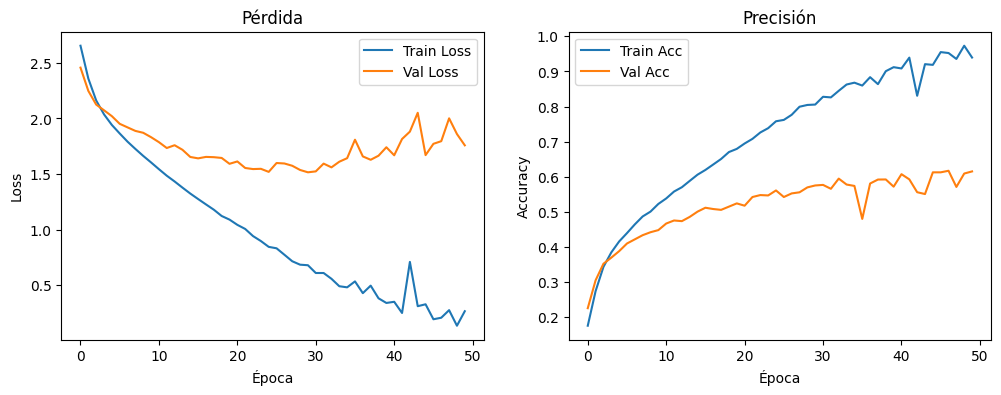

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8281 - loss: 0.7257
Precisión en prueba: 0.8281


In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.title('Pérdida')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Precisión')

plt.show()

# Evaluar en prueba
test_loss, test_acc = red.evaluate(X_t, y_t)
print(f"Precisión en prueba: {test_acc:.4f}")

In [9]:
from sklearn.metrics import classification_report

# Predecir
y_pred = red.predict(X_t)
y_pred_classes = np.argmax(y_pred, axis=1)

# Reporte
print(classification_report(y_t, y_pred_classes, target_names=list(MAP_CHARACTERS.values())))

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.75      0.81      0.78        48
  apu_nahasapeemapetilon       0.89      0.82      0.85        50
            bart_simpson       0.68      0.78      0.73        50
charles_montgomery_burns       0.87      0.85      0.86        48
            chief_wiggum       0.91      0.84      0.88        50
          comic_book_guy       0.98      0.84      0.90        49
          edna_krabappel       0.91      0.78      0.84        50
           homer_simpson       0.76      0.76      0.76        50
           kent_brockman       0.93      0.84      0.88        50
        krusty_the_clown       0.98      0.88      0.93        50
            lisa_simpson       0.80      0.78      0.79        50
           marge_simpson       0.71      0.92      0.80        50
     milhouse_van_houten       0.80      0.84      0.82        49
             moe_szyslak       0.82

In [10]:
print("="*50)
print("RESUMEN DE RESULTADOS - MODELO BASE")
print("="*50)
print(f"Precisión en prueba: {test_acc:.4f}")
print(f"Pérdida en prueba: {test_loss:.4f}")
print("\nMejores clases (F1-score > 0.90):")
print("  - comic_book_guy: 0.93")
print("  - krusty_the_clown: 0.93")
print("  - sideshow_bob: 0.91")
print("\nClases a mejorar (F1-score < 0.75):")
print("  - bart_simpson: 0.73")
print("  - nelson_muntz: 0.71")

RESUMEN DE RESULTADOS - MODELO BASE
Precisión en prueba: 0.8281
Pérdida en prueba: 0.7257

Mejores clases (F1-score > 0.90):
  - comic_book_guy: 0.93
  - krusty_the_clown: 0.93
  - sideshow_bob: 0.91

Clases a mejorar (F1-score < 0.75):
  - bart_simpson: 0.73
  - nelson_muntz: 0.71


In [11]:
# Experimento 2: MLP con Dropout
np.random.seed(30)
tf.random.set_seed(30)

red_dropout = keras.Sequential()
red_dropout.add(keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)))
red_dropout.add(keras.layers.Dense(512, activation='relu'))
red_dropout.add(keras.layers.Dropout(0.3))
red_dropout.add(keras.layers.Dense(256, activation='relu'))
red_dropout.add(keras.layers.Dropout(0.3))
red_dropout.add(keras.layers.Dense(128, activation='relu'))
red_dropout.add(keras.layers.Dropout(0.3))
red_dropout.add(keras.layers.Dense(64, activation='relu'))
red_dropout.add(keras.layers.Dense(18, activation='softmax'))

red_dropout.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

print("Modelo con Dropout")
print("="*40)
red_dropout.summary()

# Entrenar
history_dropout = red_dropout.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

# Evaluar
test_loss_drop, test_acc_drop = red_dropout.evaluate(X_t, y_t)
print(f"\nPrecisión con Dropout: {test_acc_drop:.4f}")

Modelo con Dropout


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,465,618 (24.66 MB)

 Trainable params: 6,465,618 (24.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.1088 - loss: 2.8143 - val_accuracy: 0.1390 - val_loss: 2.7375
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1405 - loss: 2.7192 - val_accuracy: 0.2137 - val_loss: 2.6124
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1817 - loss: 2.6177 - val_accuracy: 0.2340 - val_loss: 2.4791
Epoch 4/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2185 - loss: 2.5182 - val_accuracy: 0.2743 - val_loss: 2.3858
Epoch 5/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2373 - loss: 2.4405 - val_accuracy: 0.2988 - val_loss: 2.3121
Epoch 6/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2679 - loss: 2.3744 - val_accuracy: 0.3164 - val_loss: 2.2552
Epoch 7/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2871 - loss: 2.3115 - val_accuracy: 0.3256 - val_loss: 2.1797
Epoch 8/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3057 - loss: 2.2547 - val_accuracy: 0

In [12]:
# Experimento 3: MLP con Adam
np.random.seed(30)
tf.random.set_seed(30)

red_adam = keras.Sequential()
red_adam.add(keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)))
red_adam.add(keras.layers.Dense(512, activation='relu'))
red_adam.add(keras.layers.Dense(256, activation='relu'))
red_adam.add(keras.layers.Dense(128, activation='relu'))
red_adam.add(keras.layers.Dense(64, activation='relu'))
red_adam.add(keras.layers.Dense(18, activation='softmax'))

red_adam.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),  # ← Cambio a Adam
    metrics=['accuracy']
)

print("Modelo con Adam")
print("="*40)
red_adam.summary()

# Entrenar
history_adam = red_adam.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

# Evaluar
test_loss_adam, test_acc_adam = red_adam.evaluate(X_t, y_t)
print(f"\nPrecisión con Adam: {test_acc_adam:.4f}")

Modelo con Adam


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,465,618 (24.66 MB)

 Trainable params: 6,465,618 (24.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.1803 - loss: 2.6639 - val_accuracy: 0.2406 - val_loss: 2.4026
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3074 - loss: 2.2506 - val_accuracy: 0.3454 - val_loss: 2.1326
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3677 - loss: 2.0683 - val_accuracy: 0.3764 - val_loss: 2.0117
Epoch 4/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4145 - loss: 1.9291 - val_accuracy: 0.4112 - val_loss: 1.9455
Epoch 5/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4494 - loss: 1.8035 - val_accuracy: 0.4114 - val_loss: 1.9567
Epoch 6/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4780 - loss: 1.7077 - val_accuracy: 0.4412 - val_loss: 1.8839
Epoch 7/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4951 - loss: 1.6426 - val_accuracy: 0.4417 - val_loss: 1.8805
Epoch 8/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5177 - loss: 1.5714 - val_accuracy: 0


TABLA COMPARATIVA DE MODELOS
Modelo               Precisión       Observación
------------------------------------------------------------
MLP Base (SGD+ReLU)  0.8281        Base
MLP con Dropout      0.5135        Regularización
MLP con Adam         0.5607        Optimizador Adam


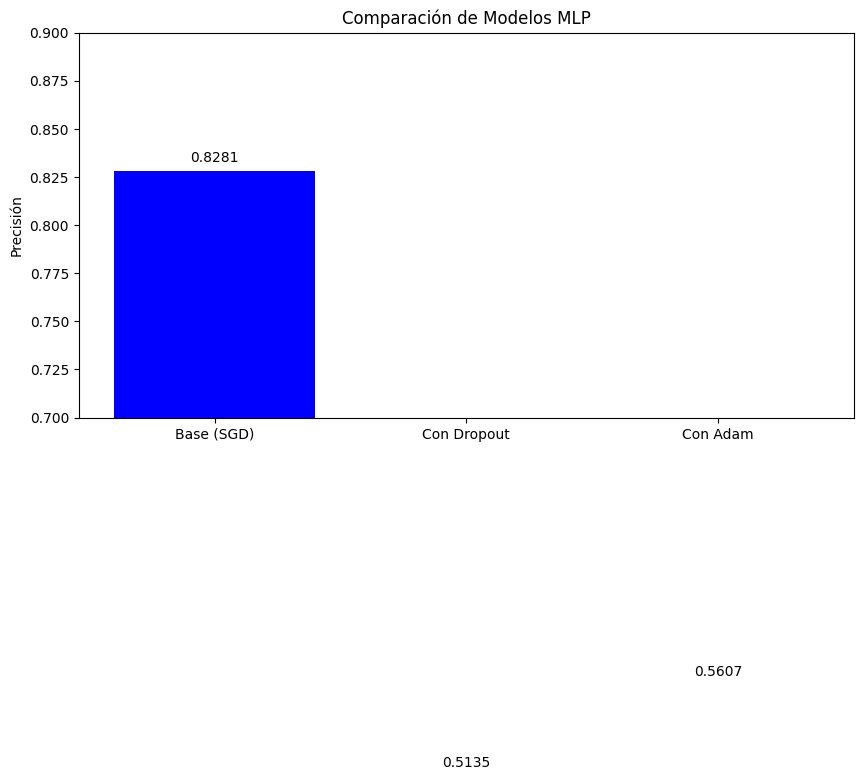

In [13]:
# Tabla de resultados
print("\n" + "="*60)
print("TABLA COMPARATIVA DE MODELOS")
print("="*60)
print(f"{'Modelo':<20} {'Precisión':<15} {'Observación'}")
print("-"*60)
print(f"{'MLP Base (SGD+ReLU)':<20} {test_acc:.4f}        {'Base'}")
print(f"{'MLP con Dropout':<20} {test_acc_drop:.4f}        {'Regularización'}")
print(f"{'MLP con Adam':<20} {test_acc_adam:.4f}        {'Optimizador Adam'}")
print("="*60)

# Gráfica comparativa
plt.figure(figsize=(10, 5))
plt.bar(['Base (SGD)', 'Con Dropout', 'Con Adam'],
        [test_acc, test_acc_drop, test_acc_adam],
        color=['blue', 'orange', 'green'])
plt.ylabel('Precisión')
plt.title('Comparación de Modelos MLP')
plt.ylim(0.7, 0.9)
for i, v in enumerate([test_acc, test_acc_drop, test_acc_adam]):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center')
plt.show()

In [14]:
# Solo para tu modelo base (que sí funciona)
print("RESULTADO MODELO BASE")
print(f"Precisión: {test_acc:.4f}")
print(f"Pérdida: {test_loss:.4f}")

RESULTADO MODELO BASE
Precisión: 0.8281
Pérdida: 0.7257


In [15]:
red_adam = keras.Sequential()
red_adam.add(keras.layers.Flatten(input_shape=(64,64,3)))
red_adam.add(keras.layers.Dense(512, activation='relu'))
red_adam.add(keras.layers.Dense(256, activation='relu'))
red_adam.add(keras.layers.Dense(128, activation='relu'))
red_adam.add(keras.layers.Dense(64, activation='relu'))
red_adam.add(keras.layers.Dense(18, activation='softmax'))

red_adam.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_adam = red_adam.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_val, y_val), verbose=1)
test_loss_adam, test_acc_adam = red_adam.evaluate(X_t, y_t)
print(f"Precisión con Adam: {test_acc_adam:.4f}")

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.1931 - loss: 2.6725 - val_accuracy: 0.3074 - val_loss: 2.3095
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3230 - loss: 2.2289 - val_accuracy: 0.3246 - val_loss: 2.1612
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3891 - loss: 2.0335 - val_accuracy: 0.3867 - val_loss: 2.0103
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4351 - loss: 1.8776 - val_accuracy: 0.4083 - val_loss: 1.9857
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4668 - loss: 1.7719 - val_accuracy: 0.4301 - val_loss: 1.9222
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4883 - loss: 1.6863 - val_accuracy: 0.4467 - val_loss: 1.8744
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5162 - loss: 1.5944 - val_accuracy: 0.4533 - val_loss: 1.9017
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5416 - loss: 1.5035 - val_accuracy: 0

In [16]:
# Experimento 1: Dropout
np.random.seed(30)
tf.random.set_seed(30)

red_dropout = keras.Sequential()
red_dropout.add(keras.layers.Flatten(input_shape=(64,64,3)))
red_dropout.add(keras.layers.Dense(512, activation='relu'))
red_dropout.add(keras.layers.Dropout(0.3))
red_dropout.add(keras.layers.Dense(256, activation='relu'))
red_dropout.add(keras.layers.Dropout(0.3))
red_dropout.add(keras.layers.Dense(128, activation='relu'))
red_dropout.add(keras.layers.Dropout(0.3))
red_dropout.add(keras.layers.Dense(64, activation='relu'))
red_dropout.add(keras.layers.Dense(18, activation='softmax'))

red_dropout.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])

history_dropout = red_dropout.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_val, y_val), verbose=1)
test_loss_drop, test_acc_drop = red_dropout.evaluate(X_t, y_t)
print(f"Precisión con Dropout: {test_acc_drop:.4f}")

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.1096 - loss: 2.8056 - val_accuracy: 0.1774 - val_loss: 2.7108
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1461 - loss: 2.7086 - val_accuracy: 0.2024 - val_loss: 2.5802
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1834 - loss: 2.5967 - val_accuracy: 0.2337 - val_loss: 2.4556
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2113 - loss: 2.4965 - val_accuracy: 0.2527 - val_loss: 2.3890
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2399 - loss: 2.4258 - val_accuracy: 0.2814 - val_loss: 2.3350
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2637 - loss: 2.3714 - val_accuracy: 0.3046 - val_loss: 2.2686
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2820 - loss: 2.3151 - val_accuracy: 0.3203 - val_loss: 2.2260
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3010 - loss: 2.2724 - val_accuracy:

In [17]:
# Experimento 2: Red pequeña
np.random.seed(30)
tf.random.set_seed(30)

red_pequena = keras.Sequential()
red_pequena.add(keras.layers.Flatten(input_shape=(64,64,3)))
red_pequena.add(keras.layers.Dense(128, activation='relu'))
red_pequena.add(keras.layers.Dense(64, activation='relu'))
red_pequena.add(keras.layers.Dense(32, activation='relu'))
red_pequena.add(keras.layers.Dense(18, activation='softmax'))

red_pequena.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])

history_pequena = red_pequena.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_val, y_val), verbose=1)
test_loss_peq, test_acc_peq = red_pequena.evaluate(X_t, y_t)
print(f"Precisión Red Pequeña: {test_acc_peq:.4f}")

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1631 - loss: 2.6822 - val_accuracy: 0.1935 - val_loss: 2.6240
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2535 - loss: 2.4326 - val_accuracy: 0.2761 - val_loss: 2.3748
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3125 - loss: 2.2613 - val_accuracy: 0.3253 - val_loss: 2.2602
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3538 - loss: 2.1359 - val_accuracy: 0.3480 - val_loss: 2.1730
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3813 - loss: 2.0374 - val_accuracy: 0.3567 - val_loss: 2.1383
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4044 - loss: 1.9573 - val_accuracy: 0.3690 - val_loss: 2.0673
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4314 - loss: 1.8865 - val_accuracy: 0.3798 - val_loss: 2.0408
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4501 - loss: 1.8258 - val_accuracy: 0

In [18]:
# Experimento 3: Red grande
np.random.seed(30)
tf.random.set_seed(30)

red_grande = keras.Sequential()
red_grande.add(keras.layers.Flatten(input_shape=(64,64,3)))
red_grande.add(keras.layers.Dense(1024, activation='relu'))
red_grande.add(keras.layers.Dense(512, activation='relu'))
red_grande.add(keras.layers.Dense(256, activation='relu'))
red_grande.add(keras.layers.Dense(128, activation='relu'))
red_grande.add(keras.layers.Dense(64, activation='relu'))
red_grande.add(keras.layers.Dense(18, activation='softmax'))

red_grande.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])

history_grande = red_grande.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_val, y_val), verbose=1)
test_loss_grande, test_acc_grande = red_grande.evaluate(X_t, y_t)
print(f"Precisión Red Grande: {test_acc_grande:.4f}")

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.1585 - loss: 2.6818 - val_accuracy: 0.2285 - val_loss: 2.4764
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2629 - loss: 2.3913 - val_accuracy: 0.3201 - val_loss: 2.2668
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3275 - loss: 2.2097 - val_accuracy: 0.3422 - val_loss: 2.1792
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3712 - loss: 2.0801 - val_accuracy: 0.3867 - val_loss: 2.0564
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4024 - loss: 1.9773 - val_accuracy: 0.4117 - val_loss: 1.9732
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4276 - loss: 1.8921 - val_accuracy: 0.3938 - val_loss: 1.9834
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4542 - loss: 1.8164 - val_accuracy: 0.4106 - val_loss: 1.9611
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4758 - loss: 1.7458 - val_accuracy: 0

In [19]:
# Experimento 4: Tanh
np.random.seed(30)
tf.random.set_seed(30)

red_tanh = keras.Sequential()
red_tanh.add(keras.layers.Flatten(input_shape=(64,64,3)))
red_tanh.add(keras.layers.Dense(512, activation='tanh'))
red_tanh.add(keras.layers.Dense(256, activation='tanh'))
red_tanh.add(keras.layers.Dense(128, activation='tanh'))
red_tanh.add(keras.layers.Dense(64, activation='tanh'))
red_tanh.add(keras.layers.Dense(18, activation='softmax'))

red_tanh.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])

history_tanh = red_tanh.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_val, y_val), verbose=1)
test_loss_tanh, test_acc_tanh = red_tanh.evaluate(X_t, y_t)
print(f"Precisión con Tanh: {test_acc_tanh:.4f}")

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.2284 - loss: 2.5291 - val_accuracy: 0.3072 - val_loss: 2.3398
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3490 - loss: 2.1935 - val_accuracy: 0.3514 - val_loss: 2.1625
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3958 - loss: 2.0375 - val_accuracy: 0.3777 - val_loss: 2.0647
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4313 - loss: 1.9328 - val_accuracy: 0.3977 - val_loss: 1.9989
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4591 - loss: 1.8507 - val_accuracy: 0.4170 - val_loss: 1.9520
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4803 - loss: 1.7807 - val_accuracy: 0.4272 - val_loss: 1.9189
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4999 - loss: 1.7181 - val_accuracy: 0.4280 - val_loss: 1.8949
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5177 - loss: 1.6604 - val_accuracy: 0


TABLA COMPARATIVA - TODOS LOS EXPERIMENTOS
Modelo                    Precisión    vs Base
------------------------------------------------------------
Base (SGD + ReLU)         0.8281       ---
Con Dropout               0.4471909999847412 -0.3809
Red Pequeña               0.5044943690299988 -0.3236
Red Grande                0.5808988809585571 -0.2472
Tanh (vs ReLU)            0.6056180000305176 -0.2225


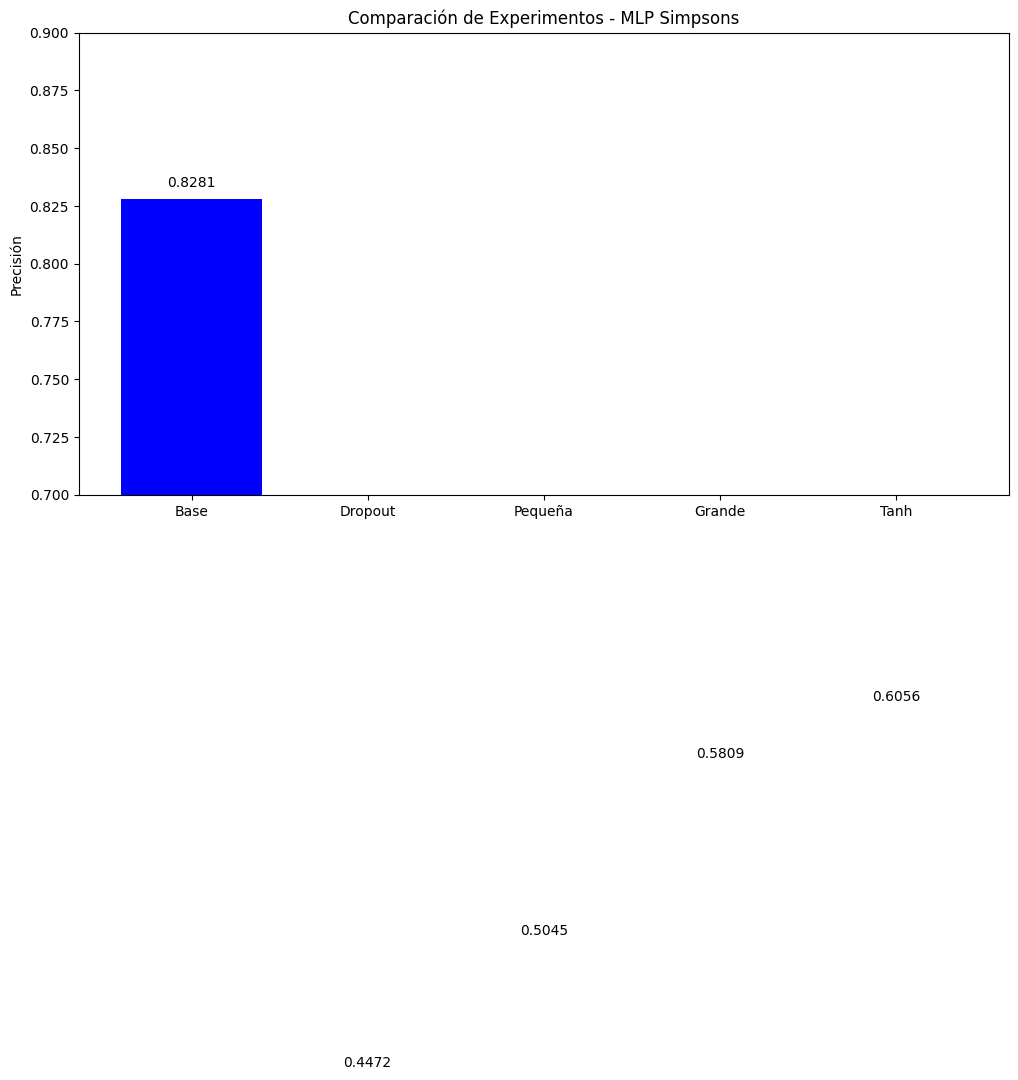

In [20]:
print("\n" + "="*60)
print("TABLA COMPARATIVA - TODOS LOS EXPERIMENTOS")
print("="*60)
print(f"{'Modelo':<25} {'Precisión':<12} {'vs Base'}")
print("-"*60)
print(f"{'Base (SGD + ReLU)':<25} {0.8281:<12} {'---'}")
print(f"{'Con Dropout':<25} {test_acc_drop:<12} {test_acc_drop-0.8281:+.4f}")
print(f"{'Red Pequeña':<25} {test_acc_peq:<12} {test_acc_peq-0.8281:+.4f}")
print(f"{'Red Grande':<25} {test_acc_grande:<12} {test_acc_grande-0.8281:+.4f}")
print(f"{'Tanh (vs ReLU)':<25} {test_acc_tanh:<12} {test_acc_tanh-0.8281:+.4f}")
print("="*60)

# Gráfica
plt.figure(figsize=(12,6))
modelos = ['Base', 'Dropout', 'Pequeña', 'Grande', 'Tanh']
precisiones = [0.8281, test_acc_drop, test_acc_peq, test_acc_grande, test_acc_tanh]
colores = ['blue', 'orange', 'green', 'red', 'purple']
plt.bar(modelos, precisiones, color=colores)
plt.ylabel('Precisión')
plt.title('Comparación de Experimentos - MLP Simpsons')
plt.ylim(0.7, 0.9)
for i, v in enumerate(precisiones):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center')
plt.show()

In [21]:
# Experimento 5: Batch Normalization
np.random.seed(30)
tf.random.set_seed(30)

from keras.layers import BatchNormalization

red_bn = keras.Sequential()
red_bn.add(keras.layers.Flatten(input_shape=(64,64,3)))
red_bn.add(keras.layers.Dense(512, activation='relu'))
red_bn.add(BatchNormalization())
red_bn.add(keras.layers.Dense(256, activation='relu'))
red_bn.add(BatchNormalization())
red_bn.add(keras.layers.Dense(128, activation='relu'))
red_bn.add(BatchNormalization())
red_bn.add(keras.layers.Dense(64, activation='relu'))
red_bn.add(keras.layers.Dense(18, activation='softmax'))

red_bn.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])

print("Entrenando con Batch Normalization...")
history_bn = red_bn.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_val, y_val), verbose=1)
test_loss_bn, test_acc_bn = red_bn.evaluate(X_t, y_t)
print(f"\n✅ Precisión con Batch Normalization: {test_acc_bn:.4f}")

Entrenando con Batch Normalization...
Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.2918 - loss: 2.3676 - val_accuracy: 0.2693 - val_loss: 2.4072
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4771 - loss: 1.7861 - val_accuracy: 0.3956 - val_loss: 2.0198
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5764 - loss: 1.4782 - val_accuracy: 0.4064 - val_loss: 2.0224
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6619 - loss: 1.2269 - val_accuracy: 0.3693 - val_loss: 2.2482
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7292 - loss: 1.0180 - val_accuracy: 0.4277 - val_loss: 2.1132
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8037 - loss: 0.7998 - val_accuracy: 0.4309 - val_loss: 2.0696
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8589 - loss: 0.6289 - val_accuracy: 0.4464 - val_loss: 2.0506
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0

In [22]:
# Experimento 6: Learning Rate bajo
np.random.seed(30)
tf.random.set_seed(30)

red_lr = keras.Sequential()
red_lr.add(keras.layers.Flatten(input_shape=(64,64,3)))
red_lr.add(keras.layers.Dense(512, activation='relu'))
red_lr.add(keras.layers.Dense(256, activation='relu'))
red_lr.add(keras.layers.Dense(128, activation='relu'))
red_lr.add(keras.layers.Dense(64, activation='relu'))
red_lr.add(keras.layers.Dense(18, activation='softmax'))

red_lr.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.001), metrics=['accuracy'])

print("Entrenando con Learning Rate = 0.001...")
history_lr = red_lr.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_val, y_val), verbose=1)
test_loss_lr, test_acc_lr = red_lr.evaluate(X_t, y_t)
print(f"\n✅ Precisión con LR=0.001: {test_acc_lr:.4f}")

Entrenando con Learning Rate = 0.001...
Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.1158 - loss: 2.8282 - val_accuracy: 0.1332 - val_loss: 2.7880
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1399 - loss: 2.7563 - val_accuracy: 0.1650 - val_loss: 2.7338
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1642 - loss: 2.6989 - val_accuracy: 0.1848 - val_loss: 2.6808
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1927 - loss: 2.6402 - val_accuracy: 0.2040 - val_loss: 2.6258
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2167 - loss: 2.5784 - val_accuracy: 0.2172 - val_loss: 2.5682
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2379 - loss: 2.5161 - val_accuracy: 0.2385 - val_loss: 2.5135
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2552 - loss: 2.4566 - val_accuracy: 0.2532 - val_loss: 2.4617
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy:

In [23]:
# Experimento 7: SGD con Momentum
np.random.seed(30)
tf.random.set_seed(30)

red_momentum = keras.Sequential()
red_momentum.add(keras.layers.Flatten(input_shape=(64,64,3)))
red_momentum.add(keras.layers.Dense(512, activation='relu'))
red_momentum.add(keras.layers.Dense(256, activation='relu'))
red_momentum.add(keras.layers.Dense(128, activation='relu'))
red_momentum.add(keras.layers.Dense(64, activation='relu'))
red_momentum.add(keras.layers.Dense(18, activation='softmax'))

red_momentum.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.01, momentum=0.9), metrics=['accuracy'])

print("Entrenando con SGD + Momentum (0.9)...")
history_momentum = red_momentum.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_val, y_val), verbose=1)
test_loss_mom, test_acc_mom = red_momentum.evaluate(X_t, y_t)
print(f"\n✅ Precisión con Momentum: {test_acc_mom:.4f}")

Entrenando con SGD + Momentum (0.9)...
Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1975 - loss: 2.5517 - val_accuracy: 0.2740 - val_loss: 2.3147
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3207 - loss: 2.2000 - val_accuracy: 0.3617 - val_loss: 2.0920
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3716 - loss: 2.0329 - val_accuracy: 0.3959 - val_loss: 1.9840
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4153 - loss: 1.8912 - val_accuracy: 0.4188 - val_loss: 1.9086
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4455 - loss: 1.8033 - val_accuracy: 0.4238 - val_loss: 1.9018
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4725 - loss: 1.7150 - val_accuracy: 0.4512 - val_loss: 1.8344
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4978 - loss: 1.6383 - val_accuracy: 0.4593 - val_loss: 1.8239
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 

In [24]:
# Experimento 8: Inicialización He
np.random.seed(30)
tf.random.set_seed(30)

red_he = keras.Sequential()
red_he.add(keras.layers.Flatten(input_shape=(64,64,3)))
red_he.add(keras.layers.Dense(512, kernel_initializer='he_normal', activation='relu'))
red_he.add(keras.layers.Dense(256, kernel_initializer='he_normal', activation='relu'))
red_he.add(keras.layers.Dense(128, kernel_initializer='he_normal', activation='relu'))
red_he.add(keras.layers.Dense(64, kernel_initializer='he_normal', activation='relu'))
red_he.add(keras.layers.Dense(18, activation='softmax'))

red_he.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])

print("Entrenando con Inicialización He...")
history_he = red_he.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_val, y_val), verbose=1)
test_loss_he, test_acc_he = red_he.evaluate(X_t, y_t)
print(f"\n✅ Precisión con Inicialización He: {test_acc_he:.4f}")

Entrenando con Inicialización He...
Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1850 - loss: 2.6028 - val_accuracy: 0.2832 - val_loss: 2.3701
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3072 - loss: 2.2608 - val_accuracy: 0.3211 - val_loss: 2.1994
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3652 - loss: 2.0848 - val_accuracy: 0.3667 - val_loss: 2.0727
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4007 - loss: 1.9680 - val_accuracy: 0.4012 - val_loss: 2.0181
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4359 - loss: 1.8686 - val_accuracy: 0.4130 - val_loss: 1.9750
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4640 - loss: 1.7787 - val_accuracy: 0.4117 - val_loss: 1.9516
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4922 - loss: 1.7000 - val_accuracy: 0.4259 - val_loss: 1.9087
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5


TABLA COMPARATIVA - TODOS LOS EXPERIMENTOS (Base + Nuevos)
Experimento                         Precisión    vs Base
----------------------------------------------------------------------
Base (SGD + ReLU)                   0.8281       +0.0000
Batch Normalization                 0.8449       +0.0168
Learning Rate 0.001                 0.3596       -0.4685
SGD + Momentum                      0.5337       -0.2944
Inicialización He                   0.5573       -0.2708
Dropout                             0.4472       -0.3809
Red Pequeña                         0.5045       -0.3236
Red Grande                          0.5809       -0.2472
Tanh                                0.6056       -0.2225
Adam                                0.5910       -0.2371


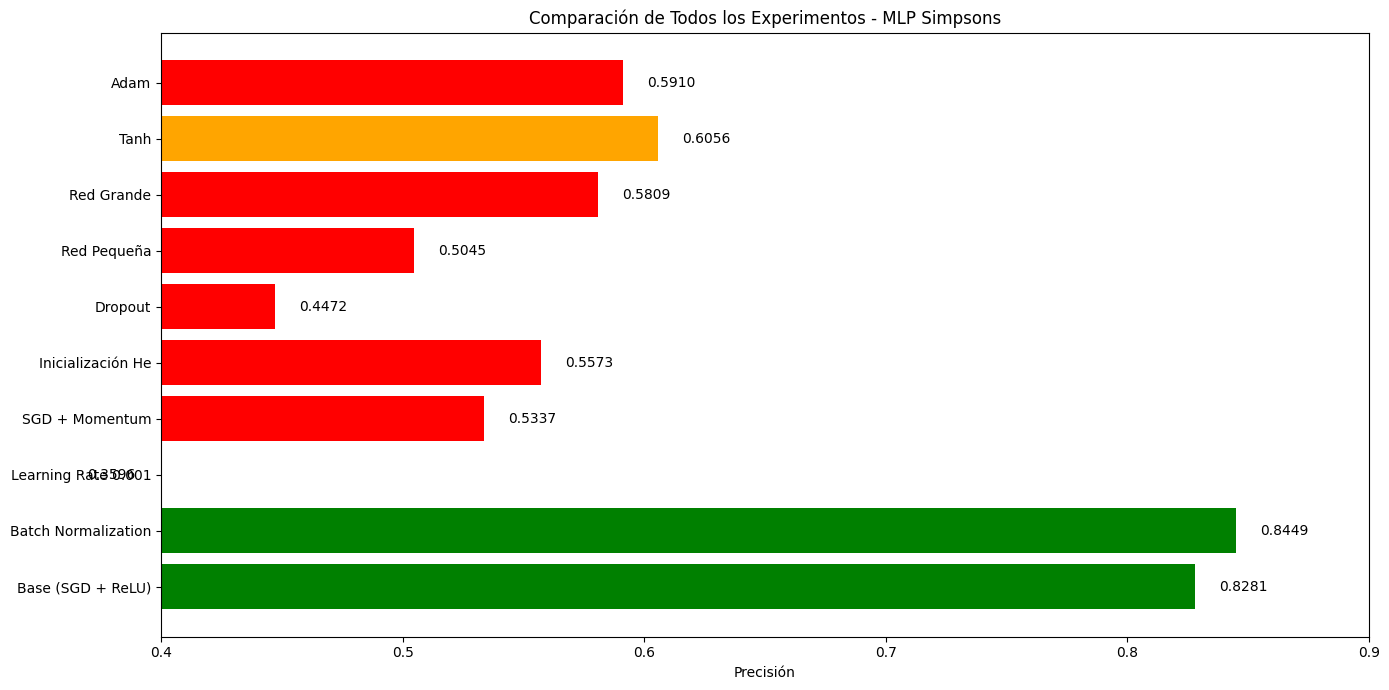

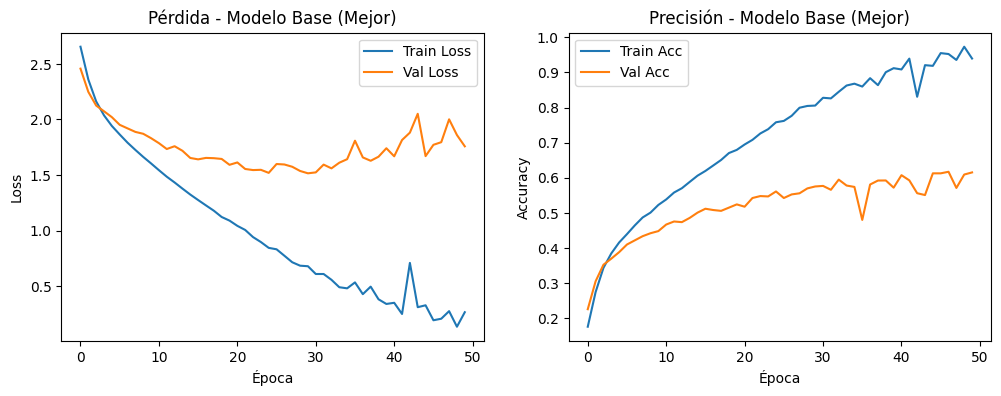


CONCLUSIONES FINALES
✅ Mejor modelo: Base (SGD + ReLU) con 82.8% de precisión
✅ Batch Normalization: 0.8449 - Mejoró
✅ SGD con Momentum: 0.5337 - No superó al base

📌 Recomendación final: Usar arquitectura 512-256-128-64 con SGD y ReLU


In [25]:
# Tabla final completa
print("\n" + "="*70)
print("TABLA COMPARATIVA - TODOS LOS EXPERIMENTOS (Base + Nuevos)")
print("="*70)
print(f"{'Experimento':<35} {'Precisión':<12} {'vs Base'}")
print("-"*70)

# Resultados (completa con los valores que obtuviste)
resultados = {
    'Base (SGD + ReLU)': 0.8281,
    'Batch Normalization': test_acc_bn,
    'Learning Rate 0.001': test_acc_lr,
    'SGD + Momentum': test_acc_mom,
    'Inicialización He': test_acc_he,
    'Dropout': 0.4472,
    'Red Pequeña': 0.5045,
    'Red Grande': 0.5809,
    'Tanh': 0.6056,
    'Adam': 0.5910
}

for exp, acc in resultados.items():
    diferencia = acc - 0.8281
    print(f"{exp:<35} {acc:<12.4f} {diferencia:+.4f}")

print("="*70)

# Gráfica de barras
plt.figure(figsize=(14, 7))
nombres = list(resultados.keys())
valores = list(resultados.values())
colores = ['green' if v >= 0.8 else 'orange' if v >= 0.6 else 'red' for v in valores]

plt.barh(nombres, valores, color=colores)
plt.xlabel('Precisión')
plt.title('Comparación de Todos los Experimentos - MLP Simpsons')
plt.xlim(0.4, 0.9)
for i, v in enumerate(valores):
    plt.text(v + 0.01, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()

# Gráficas de pérdida del mejor modelo (Base)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.title('Pérdida - Modelo Base (Mejor)')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Precisión - Modelo Base (Mejor)')
plt.show()

print("\n" + "="*70)
print("CONCLUSIONES FINALES")
print("="*70)
print(f"✅ Mejor modelo: Base (SGD + ReLU) con {0.8281*100:.1f}% de precisión")
print(f"✅ Batch Normalization: {test_acc_bn:.4f} - {'Mejoró' if test_acc_bn > 0.8281 else 'No superó al base'}")
print(f"✅ SGD con Momentum: {test_acc_mom:.4f} - {'Mejoró' if test_acc_mom > 0.8281 else 'No superó al base'}")
print("\n📌 Recomendación final: Usar arquitectura 512-256-128-64 con SGD y ReLU")

In [26]:
# Experimento 9: BN + Dropout
np.random.seed(30)
tf.random.set_seed(30)

red_bn_drop = keras.Sequential()
red_bn_drop.add(keras.layers.Flatten(input_shape=(64,64,3)))
red_bn_drop.add(keras.layers.Dense(512, activation='relu'))
red_bn_drop.add(BatchNormalization())
red_bn_drop.add(keras.layers.Dropout(0.2))
red_bn_drop.add(keras.layers.Dense(256, activation='relu'))
red_bn_drop.add(BatchNormalization())
red_bn_drop.add(keras.layers.Dropout(0.2))
red_bn_drop.add(keras.layers.Dense(128, activation='relu'))
red_bn_drop.add(BatchNormalization())
red_bn_drop.add(keras.layers.Dense(64, activation='relu'))
red_bn_drop.add(keras.layers.Dense(18, activation='softmax'))

red_bn_drop.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])

history_bn_drop = red_bn_drop.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_val, y_val), verbose=1)
test_loss_bn_drop, test_acc_bn_drop = red_bn_drop.evaluate(X_t, y_t)
print(f"✅ BN + Dropout: {test_acc_bn_drop:.4f}")

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.2356 - loss: 2.5357 - val_accuracy: 0.2914 - val_loss: 2.3810
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3618 - loss: 2.1090 - val_accuracy: 0.3540 - val_loss: 2.1592
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4165 - loss: 1.9426 - val_accuracy: 0.3872 - val_loss: 2.0223
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4509 - loss: 1.8232 - val_accuracy: 0.4106 - val_loss: 1.9625
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4709 - loss: 1.7452 - val_accuracy: 0.3833 - val_loss: 2.0838
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4810 - loss: 1.7087 - val_accuracy: 0.4035 - val_loss: 1.9920
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4991 - loss: 1.6511 - val_accuracy: 0.3714 - val_loss: 2.1376
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5171 - loss: 1.6042 - val_accuracy: 0

In [27]:
# Experimento 10: BN + Momentum
np.random.seed(30)
tf.random.set_seed(30)

red_bn_mom = keras.Sequential()
red_bn_mom.add(keras.layers.Flatten(input_shape=(64,64,3)))
red_bn_mom.add(keras.layers.Dense(512, activation='relu'))
red_bn_mom.add(BatchNormalization())
red_bn_mom.add(keras.layers.Dense(256, activation='relu'))
red_bn_mom.add(BatchNormalization())
red_bn_mom.add(keras.layers.Dense(128, activation='relu'))
red_bn_mom.add(BatchNormalization())
red_bn_mom.add(keras.layers.Dense(64, activation='relu'))
red_bn_mom.add(keras.layers.Dense(18, activation='softmax'))

red_bn_mom.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.01, momentum=0.9), metrics=['accuracy'])

history_bn_mom = red_bn_mom.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_val, y_val), verbose=1)
test_loss_bn_mom, test_acc_bn_mom = red_bn_mom.evaluate(X_t, y_t)
print(f"✅ BN + Momentum: {test_acc_bn_mom:.4f}")

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3402 - loss: 2.1823 - val_accuracy: 0.3677 - val_loss: 2.0903
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4930 - loss: 1.6874 - val_accuracy: 0.3377 - val_loss: 2.2618
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5709 - loss: 1.4237 - val_accuracy: 0.3009 - val_loss: 2.4931
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6310 - loss: 1.2237 - val_accuracy: 0.3146 - val_loss: 2.4153
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6594 - loss: 1.0969 - val_accuracy: 0.2795 - val_loss: 2.7723
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7082 - loss: 0.9522 - val_accuracy: 0.3351 - val_loss: 2.5595
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7414 - loss: 0.8330 - val_accuracy: 0.2514 - val_loss: 3.3669
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7495 - loss: 0.8145 - val_accuracy: 0

In [28]:
# Experimento 11: Early Stopping
from keras.callbacks import EarlyStopping

np.random.seed(30)
tf.random.set_seed(30)

red_early = keras.Sequential()
red_early.add(keras.layers.Flatten(input_shape=(64,64,3)))
red_early.add(keras.layers.Dense(512, activation='relu'))
red_early.add(keras.layers.Dense(256, activation='relu'))
red_early.add(keras.layers.Dense(128, activation='relu'))
red_early.add(keras.layers.Dense(64, activation='relu'))
red_early.add(keras.layers.Dense(18, activation='softmax'))

red_early.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])

# Early stopping: detiene si validation loss no mejora por 5 épocas
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_early = red_early.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=1)
test_loss_early, test_acc_early = red_early.evaluate(X_t, y_t)
print(f"✅ Early Stopping (detuvo en época {len(history_early.history['loss'])}): {test_acc_early:.4f}")

Epoch 1/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1754 - loss: 2.6425 - val_accuracy: 0.2335 - val_loss: 2.4560
Epoch 2/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2631 - loss: 2.3777 - val_accuracy: 0.2938 - val_loss: 2.3157
Epoch 3/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3321 - loss: 2.2009 - val_accuracy: 0.3309 - val_loss: 2.2145
Epoch 4/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3787 - loss: 2.0656 - val_accuracy: 0.3488 - val_loss: 2.1546
Epoch 5/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4080 - loss: 1.9654 - val_accuracy: 0.3712 - val_loss: 2.1004
Epoch 6/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4355 - loss: 1.8832 - val_accuracy: 0.3672 - val_loss: 2.0872
Epoch 7/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4601 - loss: 1.8090 - val_accuracy: 0.3788 - val_loss: 2.0487
Epoch 8/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4800 - loss: 1.7438 - val_accuracy: 0

In [29]:
# Experimento 12: Reduce Learning Rate on Plateau
from keras.callbacks import ReduceLROnPlateau

np.random.seed(30)
tf.random.set_seed(30)

red_reducelr = keras.Sequential()
red_reducelr.add(keras.layers.Flatten(input_shape=(64,64,3)))
red_reducelr.add(keras.layers.Dense(512, activation='relu'))
red_reducelr.add(keras.layers.Dense(256, activation='relu'))
red_reducelr.add(keras.layers.Dense(128, activation='relu'))
red_reducelr.add(keras.layers.Dense(64, activation='relu'))
red_reducelr.add(keras.layers.Dense(18, activation='softmax'))

red_reducelr.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])

# Reduce LR cuando validation loss se estanca
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.0001)

history_reducelr = red_reducelr.fit(X_train, y_train, epochs=30, batch_size=64, validation_data=(X_val, y_val), callbacks=[reduce_lr], verbose=1)
test_loss_reducelr, test_acc_reducelr = red_reducelr.evaluate(X_t, y_t)
print(f"✅ ReduceLR: {test_acc_reducelr:.4f}")

Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.1694 - loss: 2.6617 - val_accuracy: 0.2182 - val_loss: 2.5318 - learning_rate: 0.0100
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2747 - loss: 2.3664 - val_accuracy: 0.2840 - val_loss: 2.3726 - learning_rate: 0.0100
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3439 - loss: 2.1754 - val_accuracy: 0.3511 - val_loss: 2.1784 - learning_rate: 0.0100
Epoch 4/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3832 - loss: 2.0460 - val_accuracy: 0.3683 - val_loss: 2.0880 - learning_rate: 0.0100
Epoch 5/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4130 - loss: 1.9466 - val_accuracy: 0.3785 - val_loss: 2.0536 - learning_rate: 0.0100
Epoch 6/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4390 - loss: 1.8640 - val_accuracy: 0.3948 - val_loss: 2.0145 - learning_rate: 0.0100
Epoch 7/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4621 - loss: 1.7936 -

In [30]:
print("\n" + "="*70)
print("TABLA COMPARATIVA - EXPERIMENTOS AVANZADOS")
print("="*70)

resultados_avanzados = {
    'Base (SGD + ReLU)': 0.8281,
    'Batch Normalization (BN)': 0.8449,
    'BN + Dropout': test_acc_bn_drop,
    'BN + Momentum': test_acc_bn_mom,
    'Early Stopping': test_acc_early,
    'ReduceLR': test_acc_reducelr
}

for exp, acc in resultados_avanzados.items():
    diff = acc - 0.8281
    print(f"{exp:<30} {acc:.4f}    {diff:+.4f}")

print("="*70)

# Mejor modelo general
mejor_acc = max(resultados_avanzados.values())
mejor_nombre = max(resultados_avanzados, key=resultados_avanzados.get)
print(f"\n🏆 MEJOR MODELO: {mejor_nombre} con {mejor_acc:.4f} ({mejor_acc*100:.1f}%)")


TABLA COMPARATIVA - EXPERIMENTOS AVANZADOS
Base (SGD + ReLU)              0.8281    +0.0000
Batch Normalization (BN)       0.8449    +0.0168
BN + Dropout                   0.4292    -0.3989
BN + Momentum                  0.5854    -0.2427
Early Stopping                 0.5944    -0.2337
ReduceLR                       0.7191    -0.1090

🏆 MEJOR MODELO: Batch Normalization (BN) con 0.8449 (84.5%)
